In [10]:
import sys

sys.path.append("../src/")

import crowding
import matplotlib.pyplot as plt
import rotations
import torch
from fft_tools import fft2
from imagegenerator import ImageGenerator
from microscope import Aberration, Detector
from pdb2mrc import PDB2MRC
from plotting_tools import *
from scattering import Scattering, complex_potential
from tqdm import tqdm
from matplotlib.collections import PatchCollection

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "2HBS"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/", assembly=1)

/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4380.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 4423.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 4466.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 4509.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 4552.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem

Assemblies available: 1, 2
2HBS: Fetching Biological Assembly 1
File already exists: ../pdb-data/2HBS-assembly1.cif


4827it [00:00, 159720.93it/s]


In [115]:
pm.max_diameter

70.2264987557542

In [116]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 0.5  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  4.42it/s]


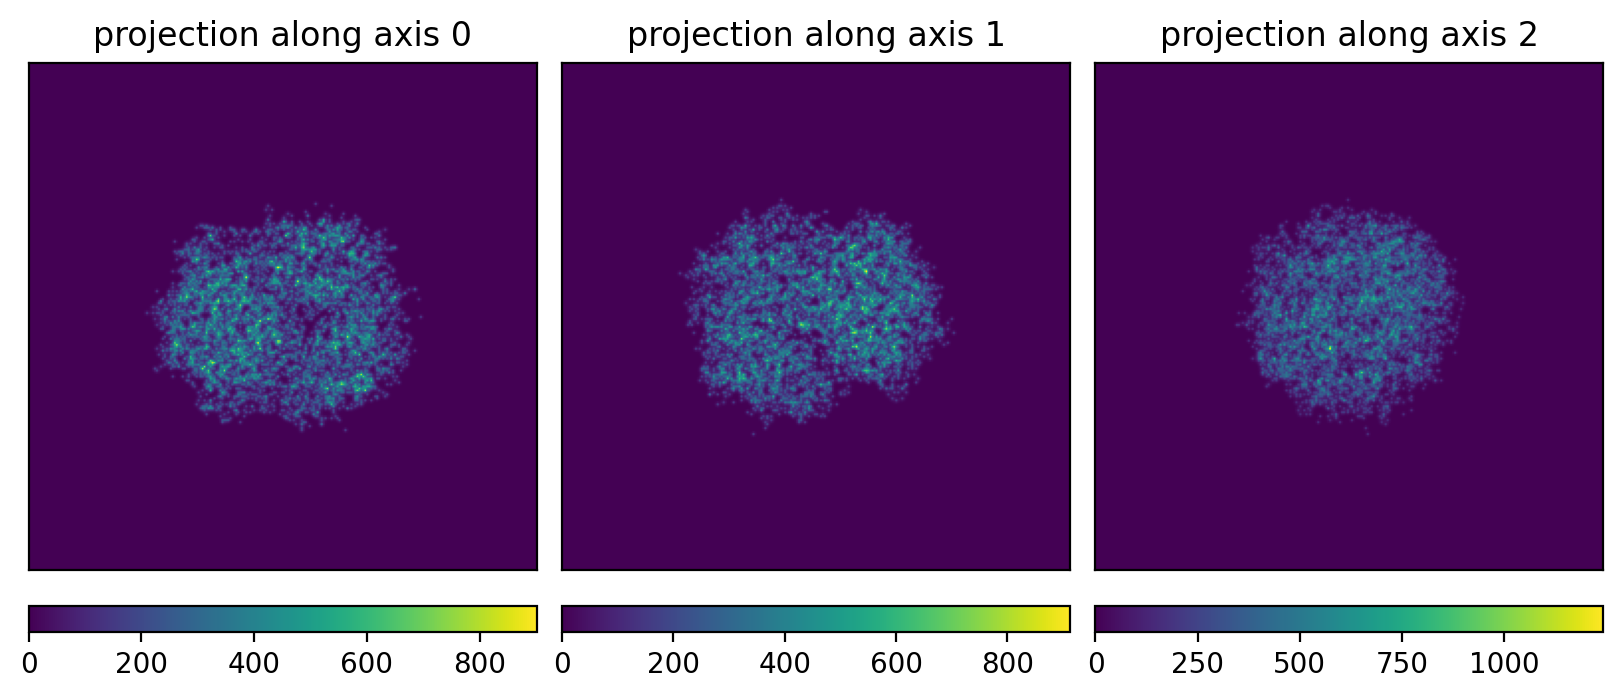

In [117]:
plot3d(V)

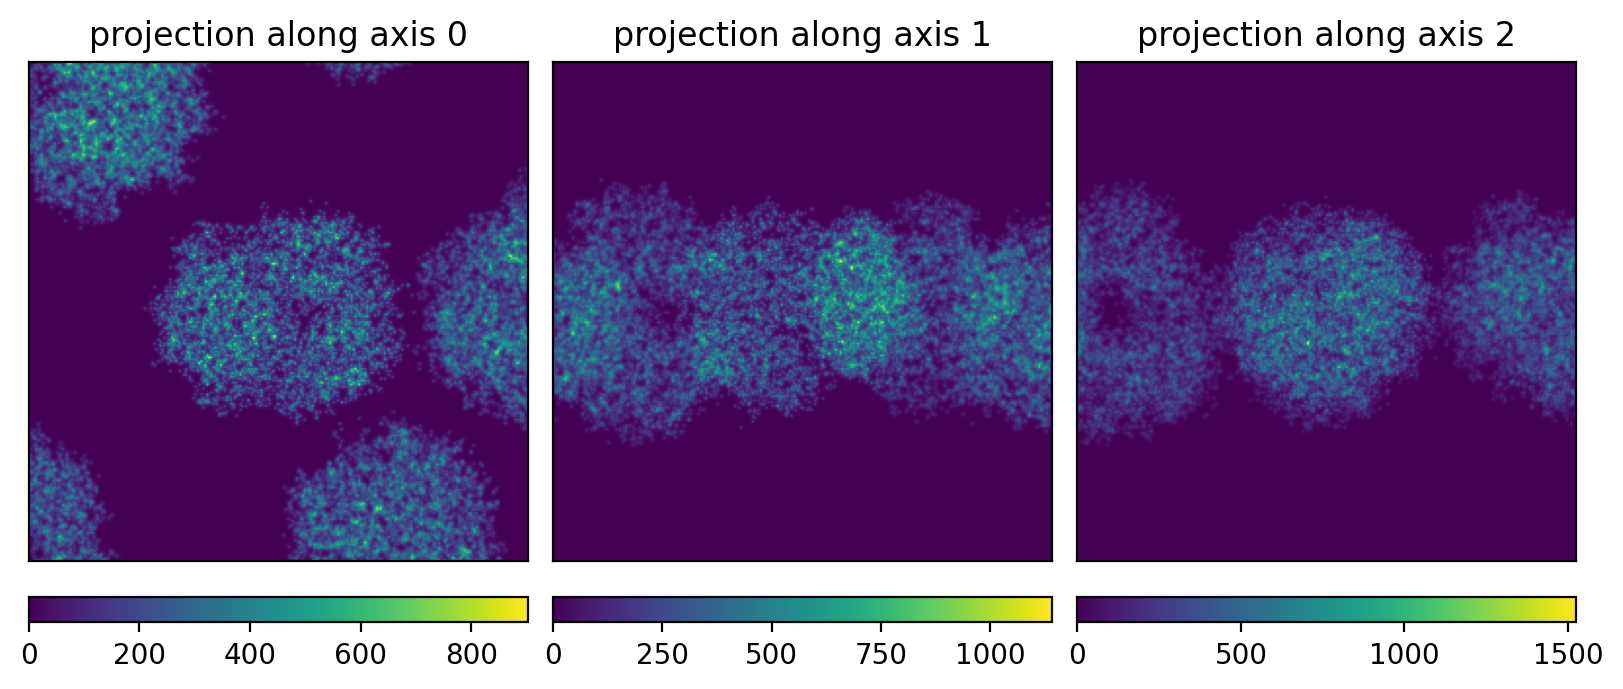

In [120]:
# num_neighbours = torch.randint(0, 6, (1,))
num_neighbours = 10
if num_neighbours > 0:
    quats = rotations.random_quaternion(num_neighbours)
    
    # quats = torch.zeros(num_neighbours, 4)
    # quats[:,-1] = 1
    
    R = rotations.quaternion_to_rotation_matrix(quats)
    if len(R.shape) == 2:
        R = R.unsqueeze(0)
    translations = crowding.poisson_disk_neighbors(
        pm.max_diameter*0.9, num_neighbours, max_radius=(n * dx + pm.max_diameter) / 2
    )
    # translations = torch.tensor([[150, 100]])
    T = rotations.translations_angstrom_to_torch(translations, n, dx)
    # theta = torch.concat([R[:len(T)], T.unsqueeze(2)], dim=-1)
    theta = rotations.build_affine_matrix(R[:len(T)], T)
    vols = rotations.rotate_volume(V, theta, padding_mode="zeros")
plot3d(V + vols.sum(0))

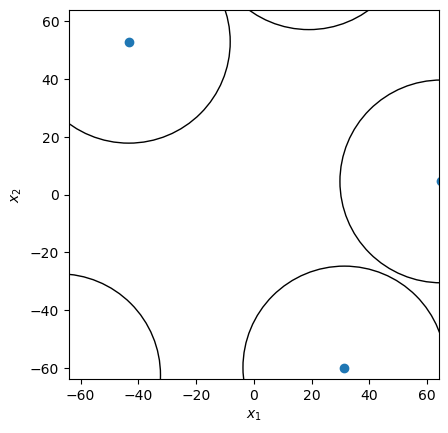

In [121]:
samples = translations

fig, ax = plt.subplots()
_ = ax.scatter(-samples[:, 0], samples[:, 1])
circles = [plt.Circle((-xi, yi), radius=pm.max_diameter / 2, fill=False) for xi, yi in samples]
collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)
_ = ax.set(
    aspect="equal", xlabel=r"$x_1$", ylabel=r"$x_2$", xlim=[-dx*n/2, dx*n/2], ylim=[-dx*n/2, dx*n/2]
)
plt.show()